In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("air_quality_index.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3295 entries, 0 to 3294
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3295 non-null   str    
 1   state          3295 non-null   str    
 2   city           3295 non-null   str    
 3   station        3295 non-null   str    
 4   last_update    3295 non-null   str    
 5   latitude       3295 non-null   float64
 6   longitude      3295 non-null   float64
 7   pollutant_id   3295 non-null   str    
 8   pollutant_min  2978 non-null   float64
 9   pollutant_max  2978 non-null   float64
 10  pollutant_avg  2978 non-null   float64
dtypes: float64(5), str(6)
memory usage: 524.3 KB


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,3295.0,23.285560,5.095973,8.514909,19.226843,23.717634,28.039521,34.066206
longitude,3295.0,78.556828,4.844293,70.776774,75.555917,77.287209,80.649110,94.636574
pollutant_min,2978.0,19.986568,20.013797,1.000000,6.000000,13.000000,28.000000,145.000000
pollutant_max,2978.0,56.697784,60.760354,1.000000,16.000000,40.000000,75.750000,500.000000
pollutant_avg,2978.0,35.039624,32.885196,1.000000,11.000000,26.000000,49.000000,333.000000


In [5]:
num_data=data.select_dtypes(include=np.number)
cat_data=data.select_dtypes(exclude=np.number)

In [6]:
cat_data.columns

Index(['country', 'state', 'city', 'station', 'last_update', 'pollutant_id'], dtype='str')

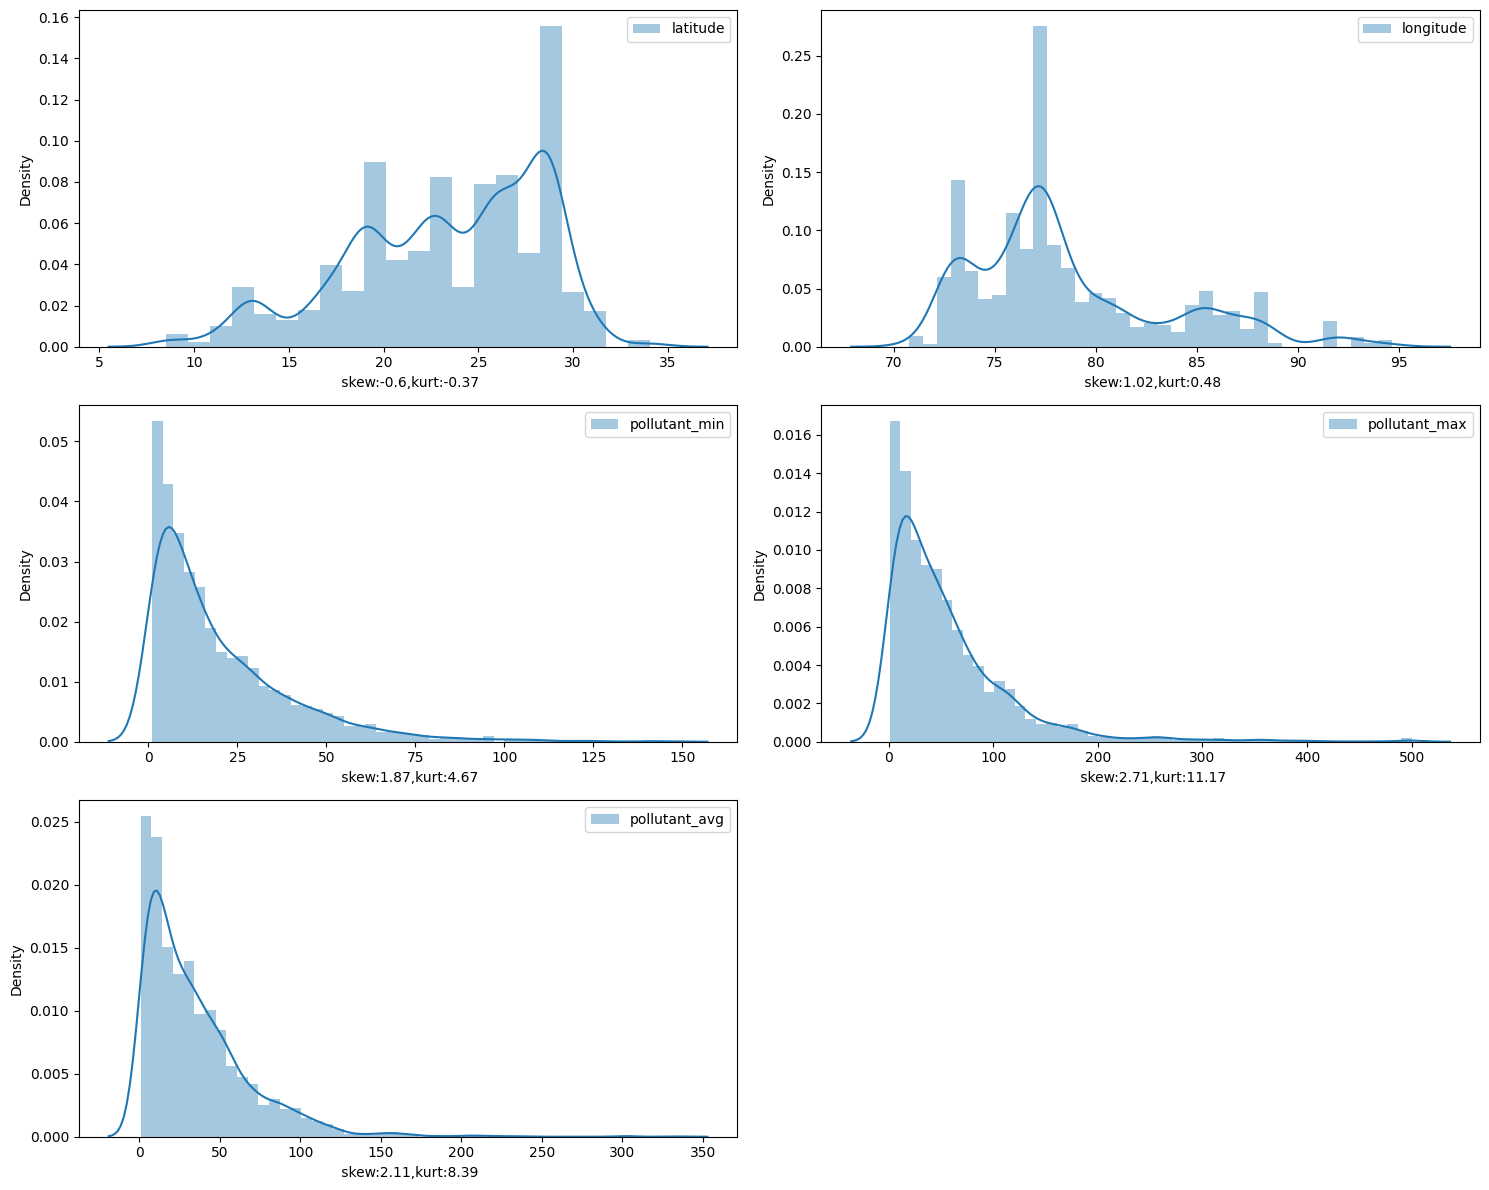

In [7]:
plt.figure(figsize=(15,12))
c=1
for i in num_data.columns:
    plt.subplot(3,2,c)
    sns.distplot(data[i],label=(i))
    plt.xlabel(f" skew:{np.round(data[i].skew(),2)},kurt:{np.round(data[i].kurt(),2)}")
    plt.legend()
    c+=1
plt.tight_layout()
plt.show()

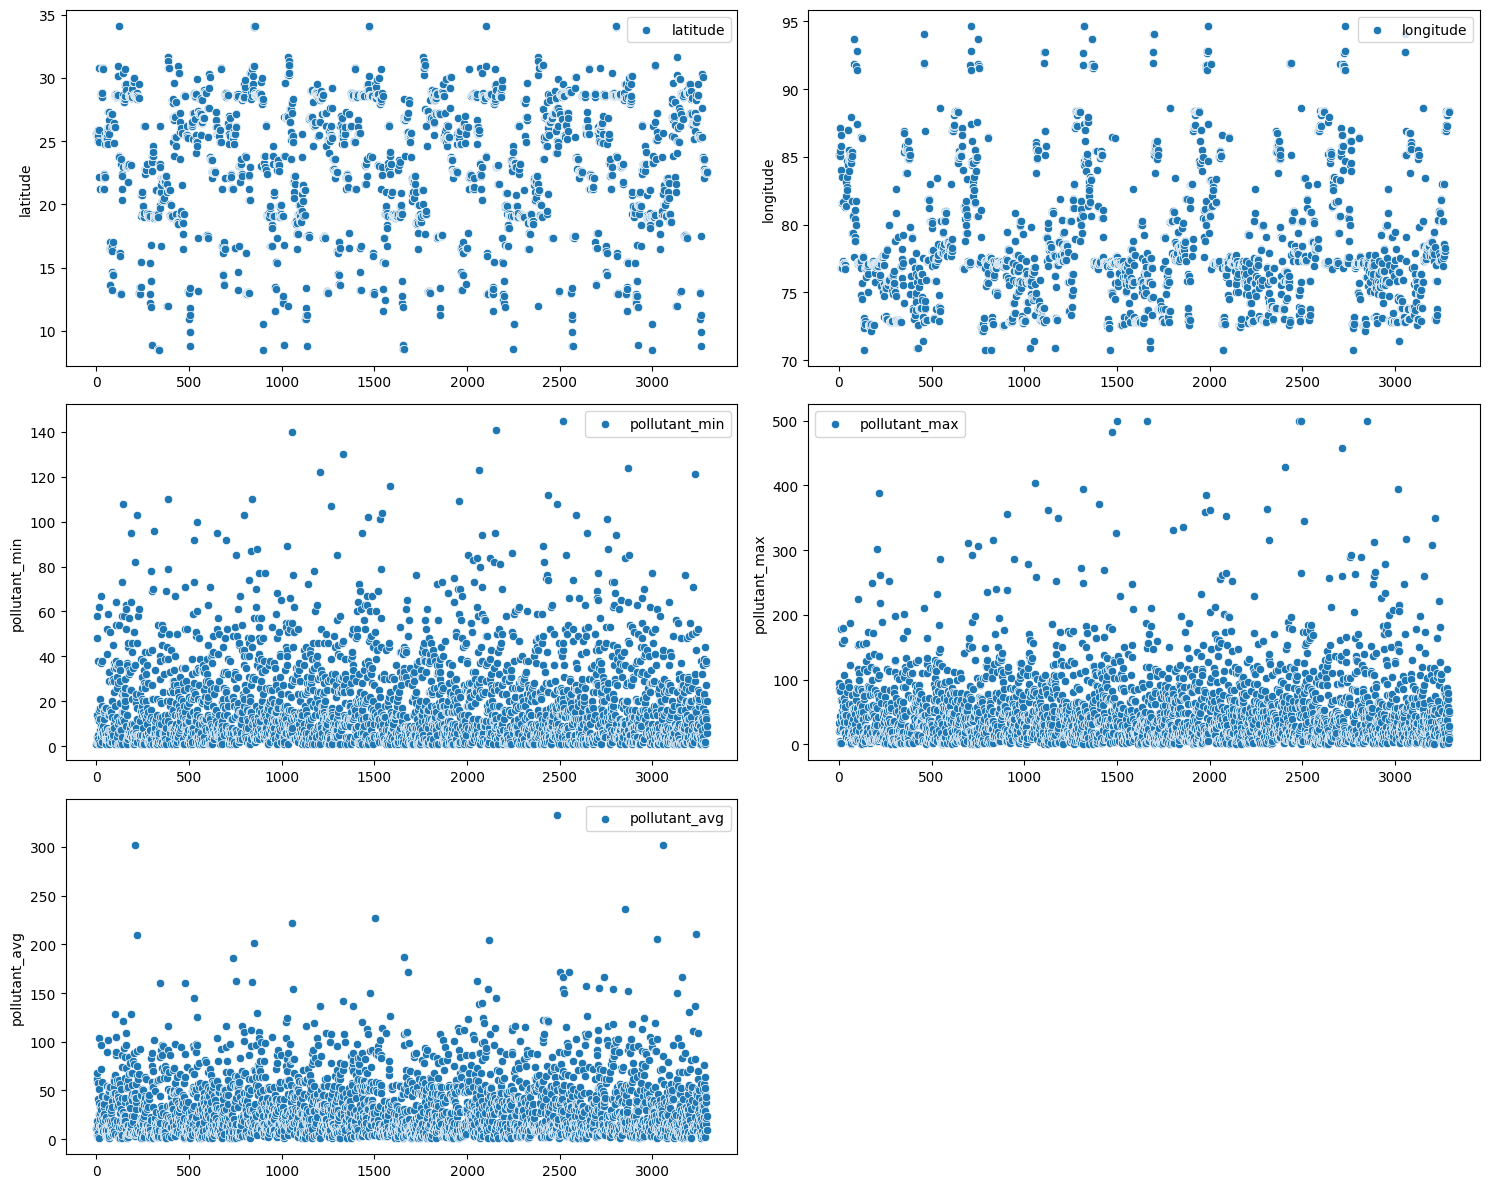

In [8]:
plt.figure(figsize=(15,12))
c=1
for i in num_data.columns:
    plt.subplot(3,2,c)
    sns.scatterplot(data[i],label=(i))
    plt.legend()
    c+=1
plt.tight_layout()
plt.show()

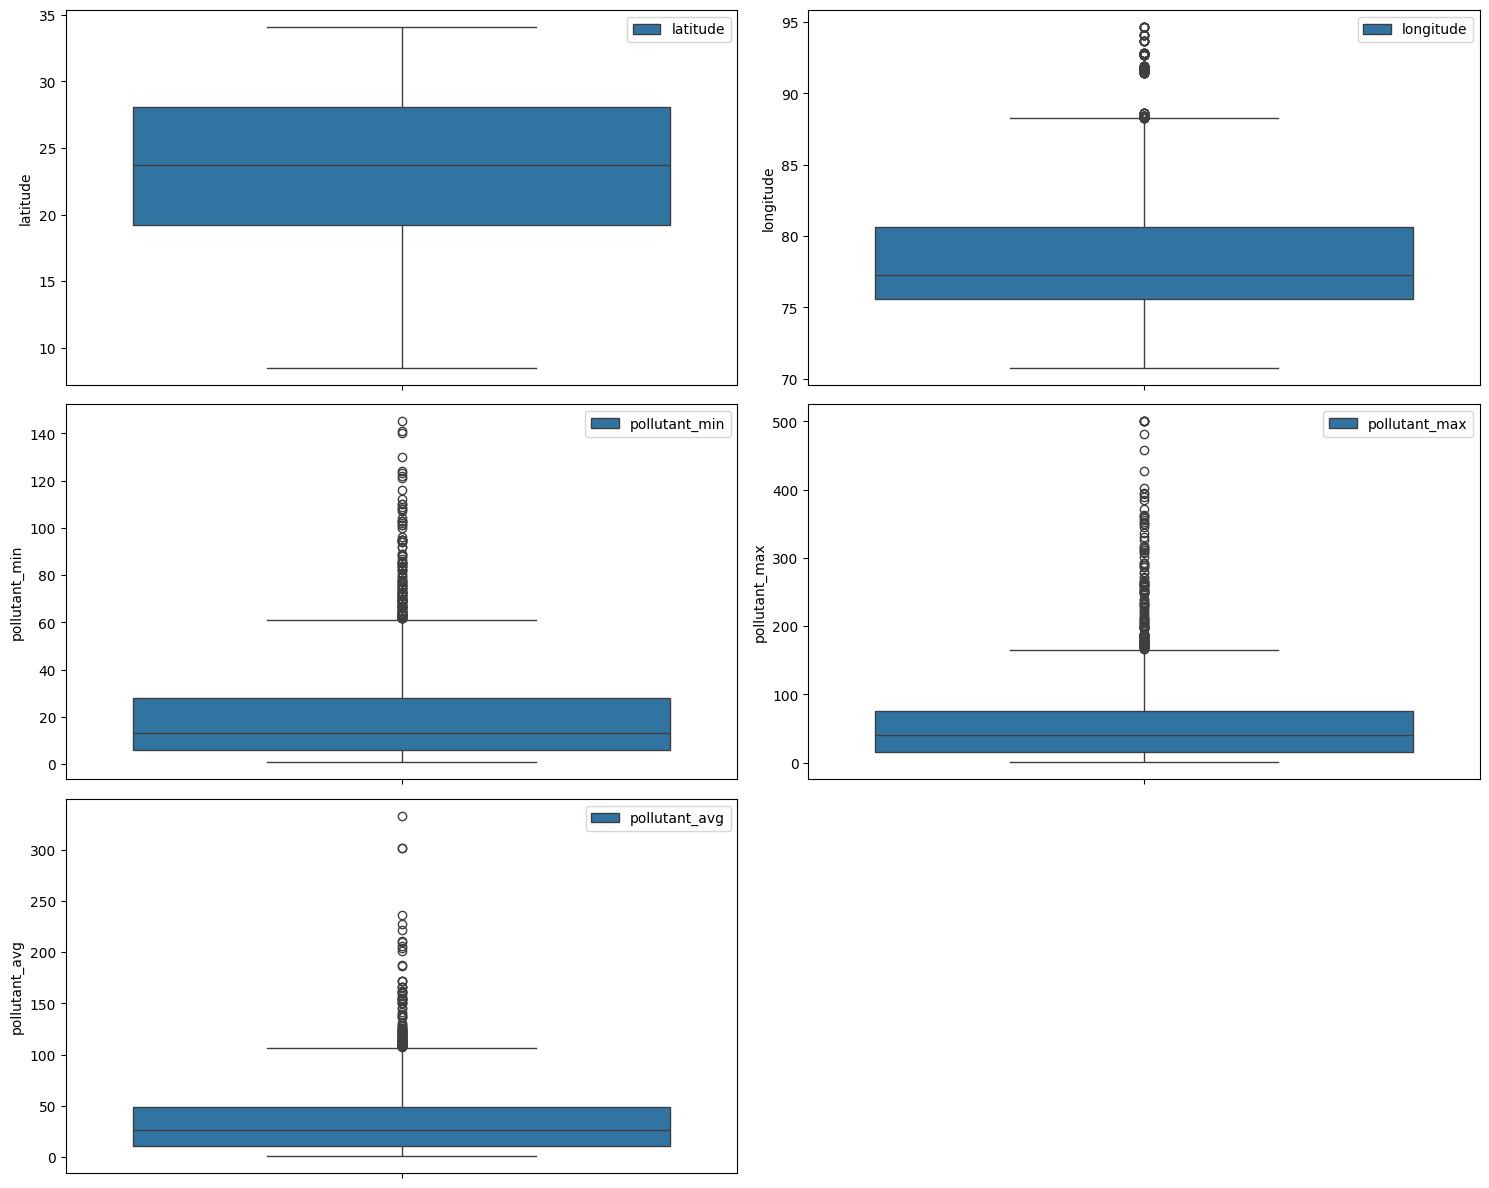

In [9]:
plt.figure(figsize=(15,12))
c=1
for i in num_data.columns:
    plt.subplot(3,2,c)
    sns.boxplot(data[i],label=(i))
    plt.legend()
    c+=1
plt.tight_layout()
plt.show()

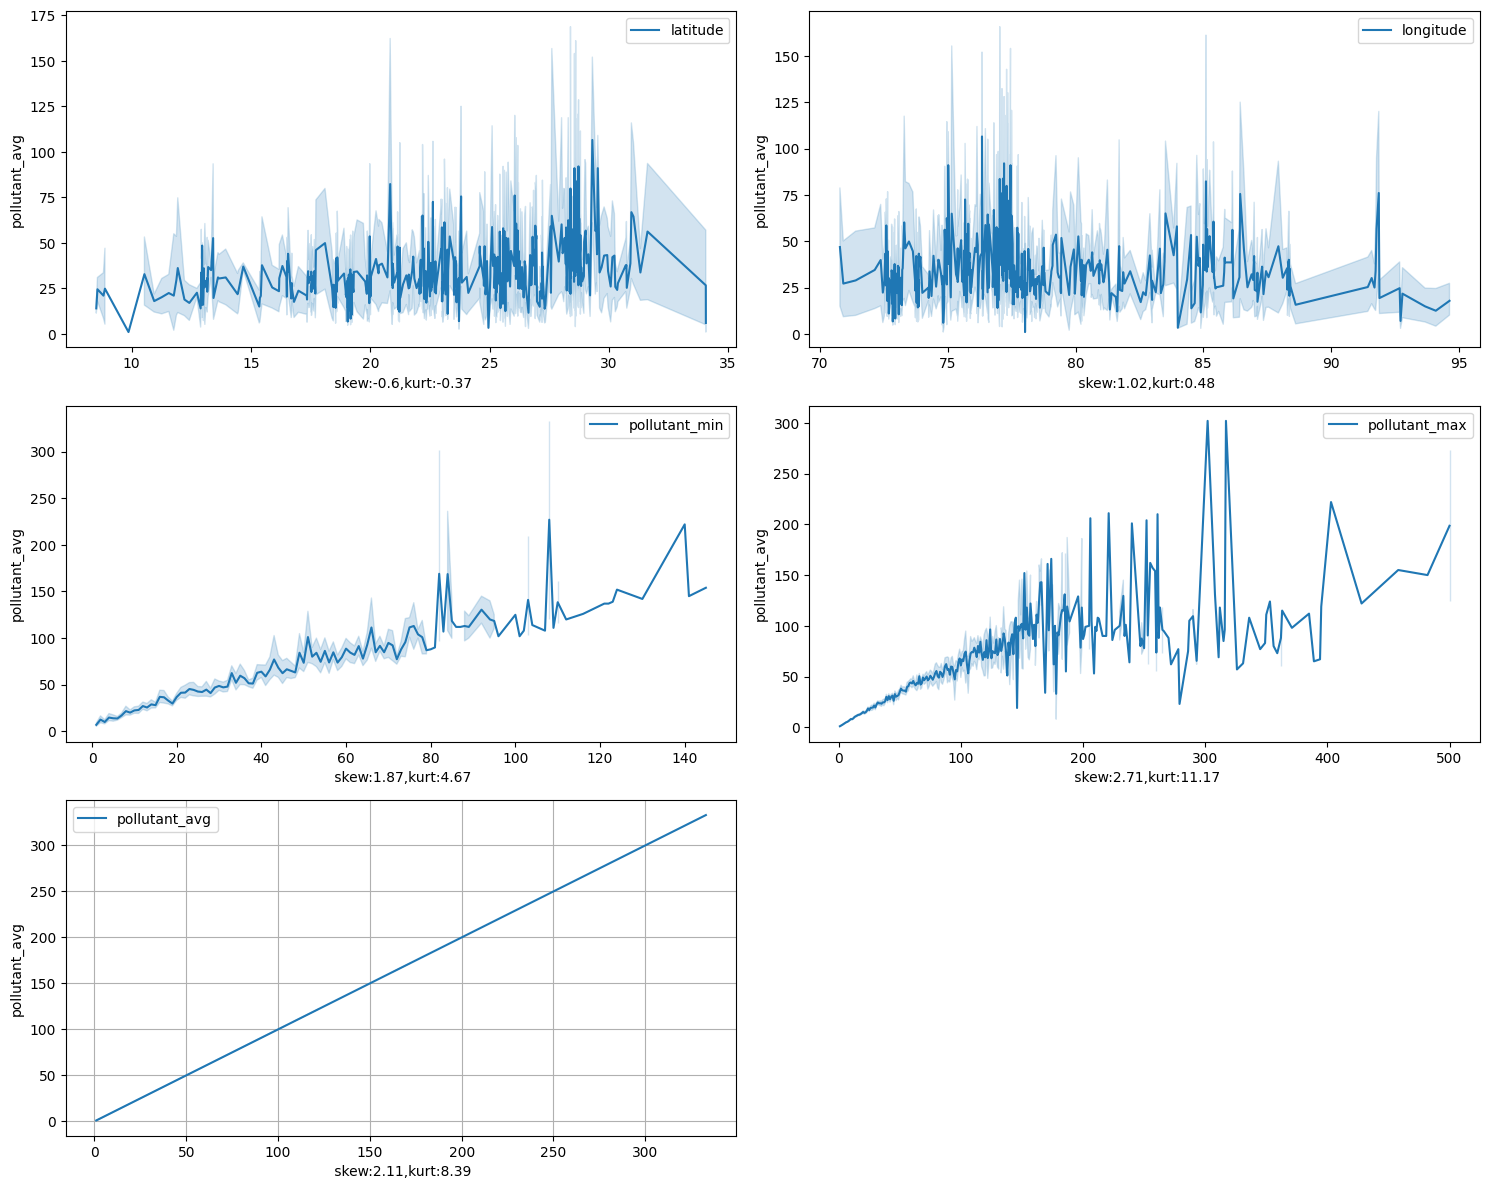

In [10]:
plt.figure(figsize=(15,12))
c=1
for i in num_data.columns:
    plt.subplot(3,2,c)
    sns.lineplot(x=data[i],y=data['pollutant_avg'],data=data,label=(i))
    plt.xlabel(f" skew:{np.round(data[i].skew(),2)},kurt:{np.round(data[i].kurt(),2)}")
    plt.legend()
    c+=1
plt.grid()
plt.tight_layout()
plt.show()

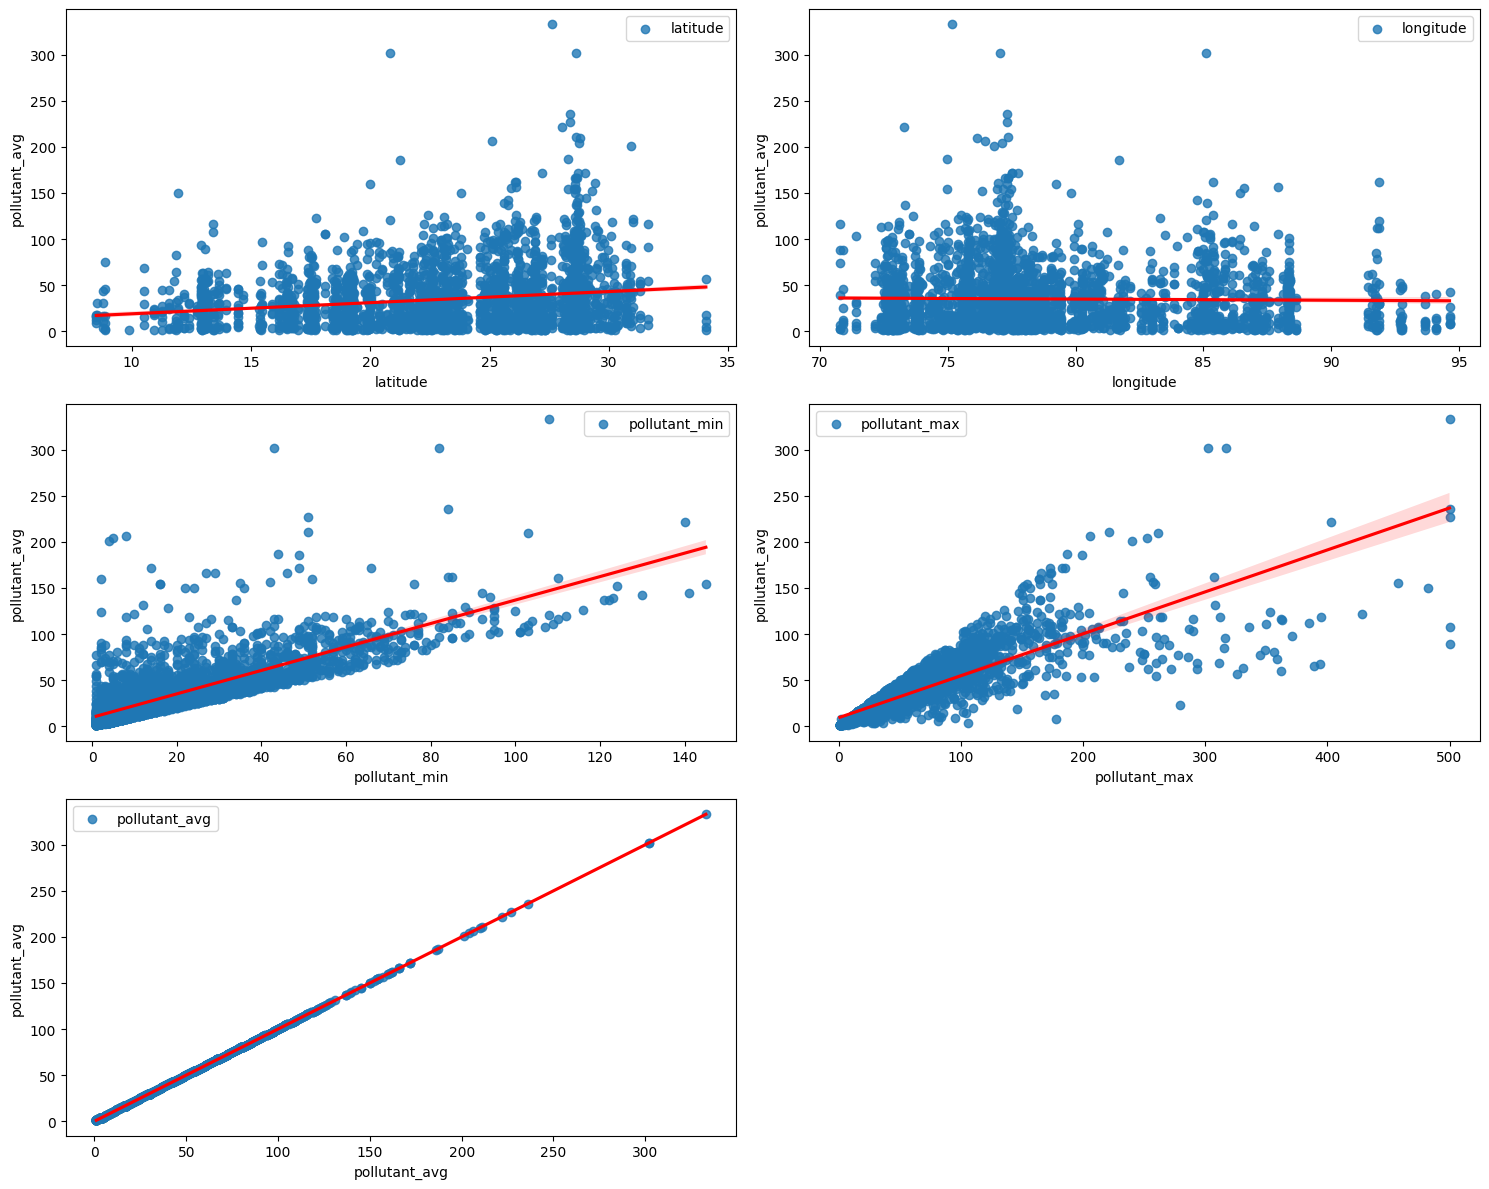

In [11]:
plt.figure(figsize=(15,12))
c=1
for i in num_data.columns:
    plt.subplot(3,2,c)
    sns.regplot(x=data[i],y=data['pollutant_avg'],data=data,line_kws=({'color':'red'}),label=(i))
    plt.legend()
    c+=1
plt.tight_layout()
plt.show()

In [12]:
cat_data_=[ 'state', 'pollutant_id']

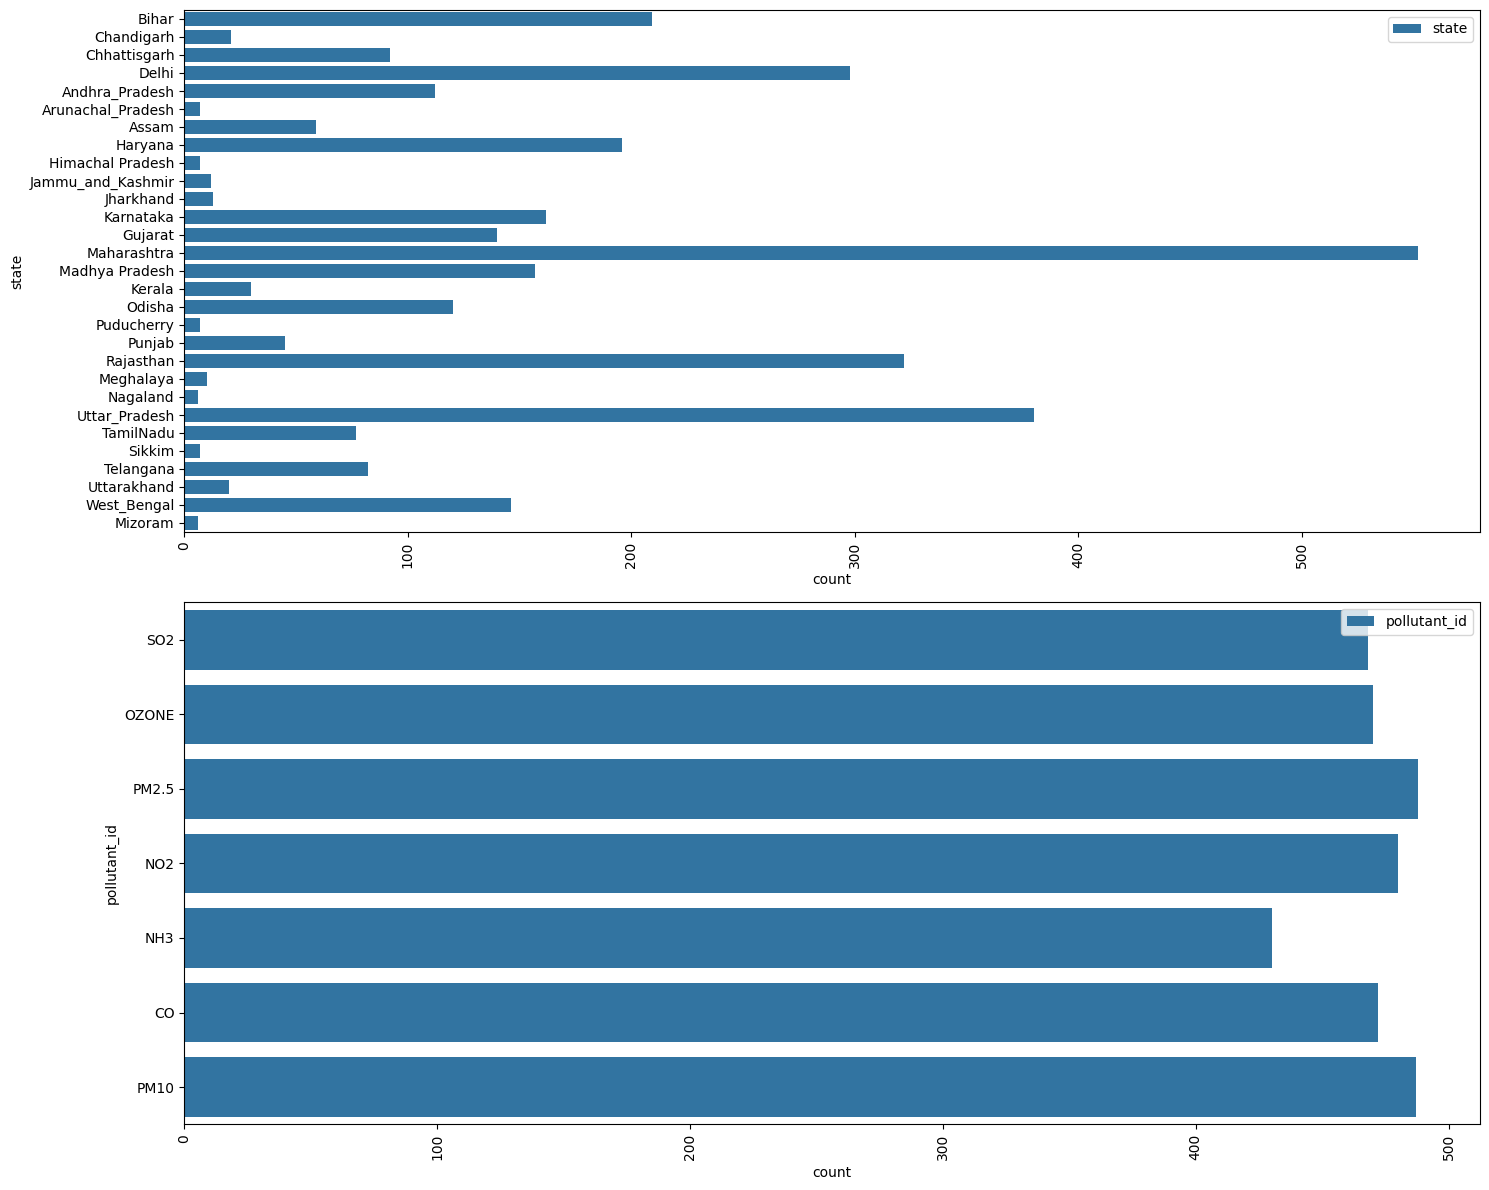

In [13]:
plt.figure(figsize=(15,12))
c=1
for i in cat_data_:
    plt.subplot(2,1,c)
    sns.countplot(data[i],label=(i))
    plt.legend()
    plt.xticks(rotation=90)
    c+=1
plt.tight_layout()
plt.show()

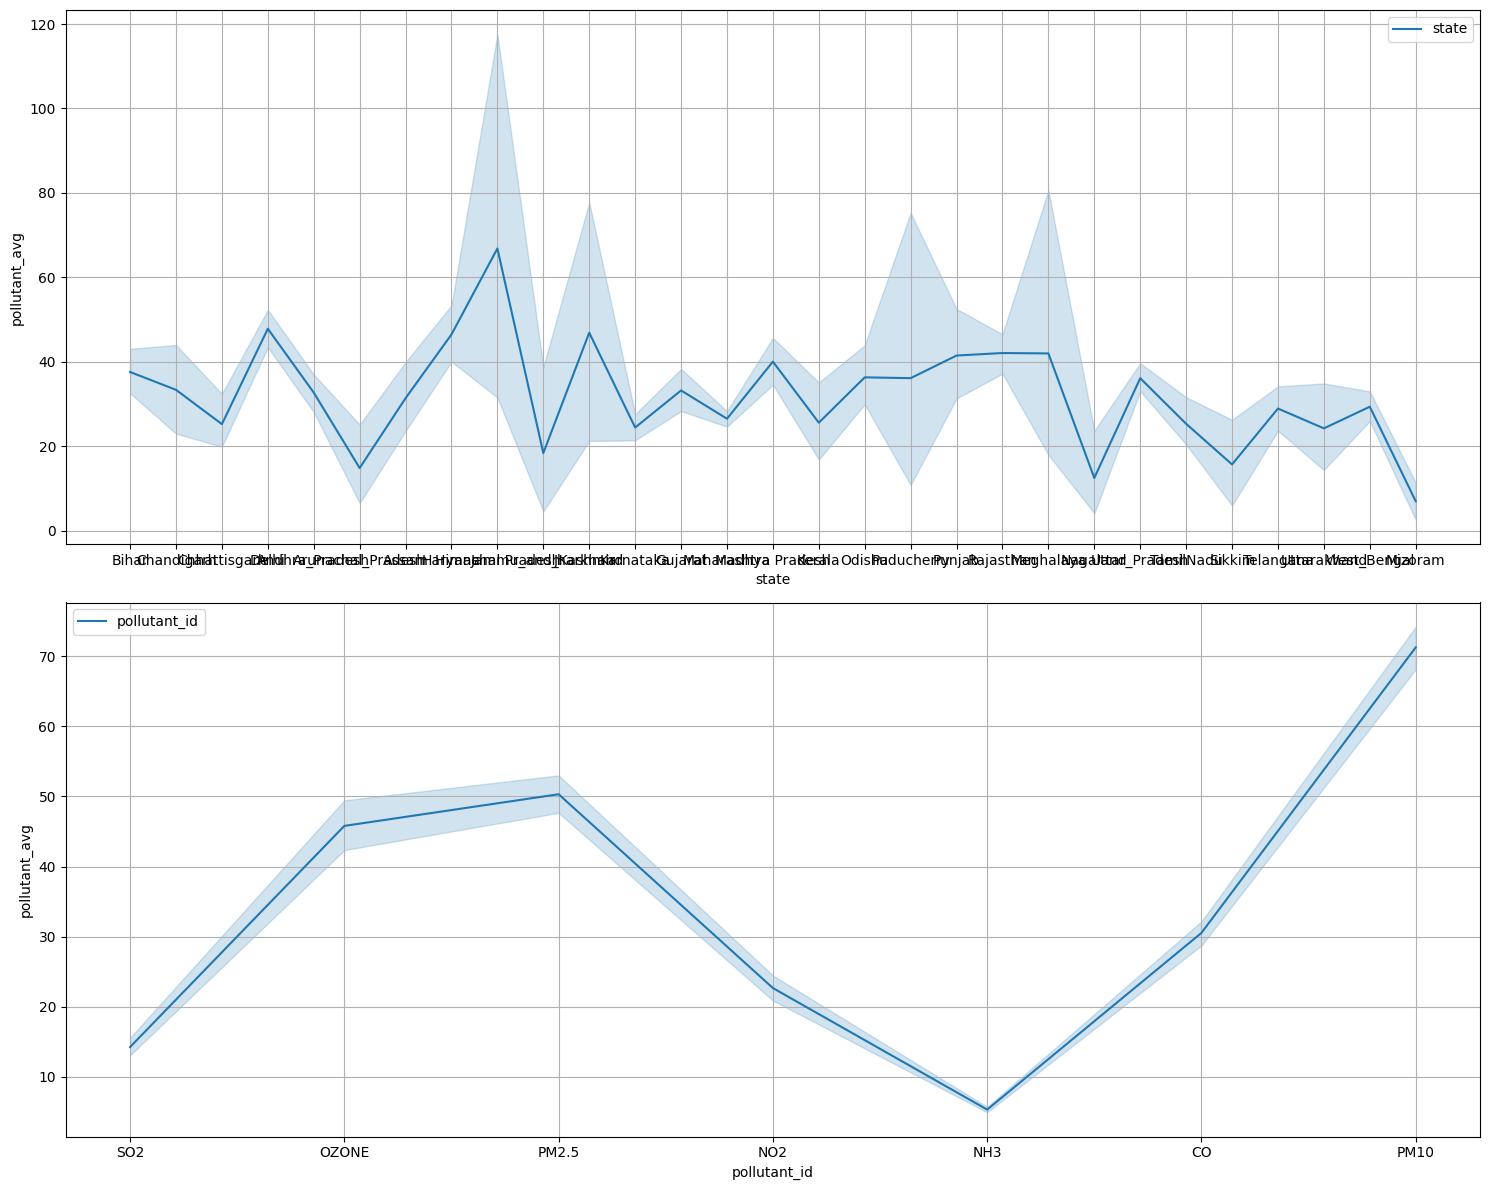

In [14]:
plt.figure(figsize=(15,12))
c=1
for i in cat_data_:
    plt.subplot(2,1,c)
    sns.lineplot(x=data[i],y=data['pollutant_avg'],data=data,label=(i))
    plt.legend()
    # plt.xticks(rotation=90)
    c+=1
    plt.grid()
plt.tight_layout()
plt.show()

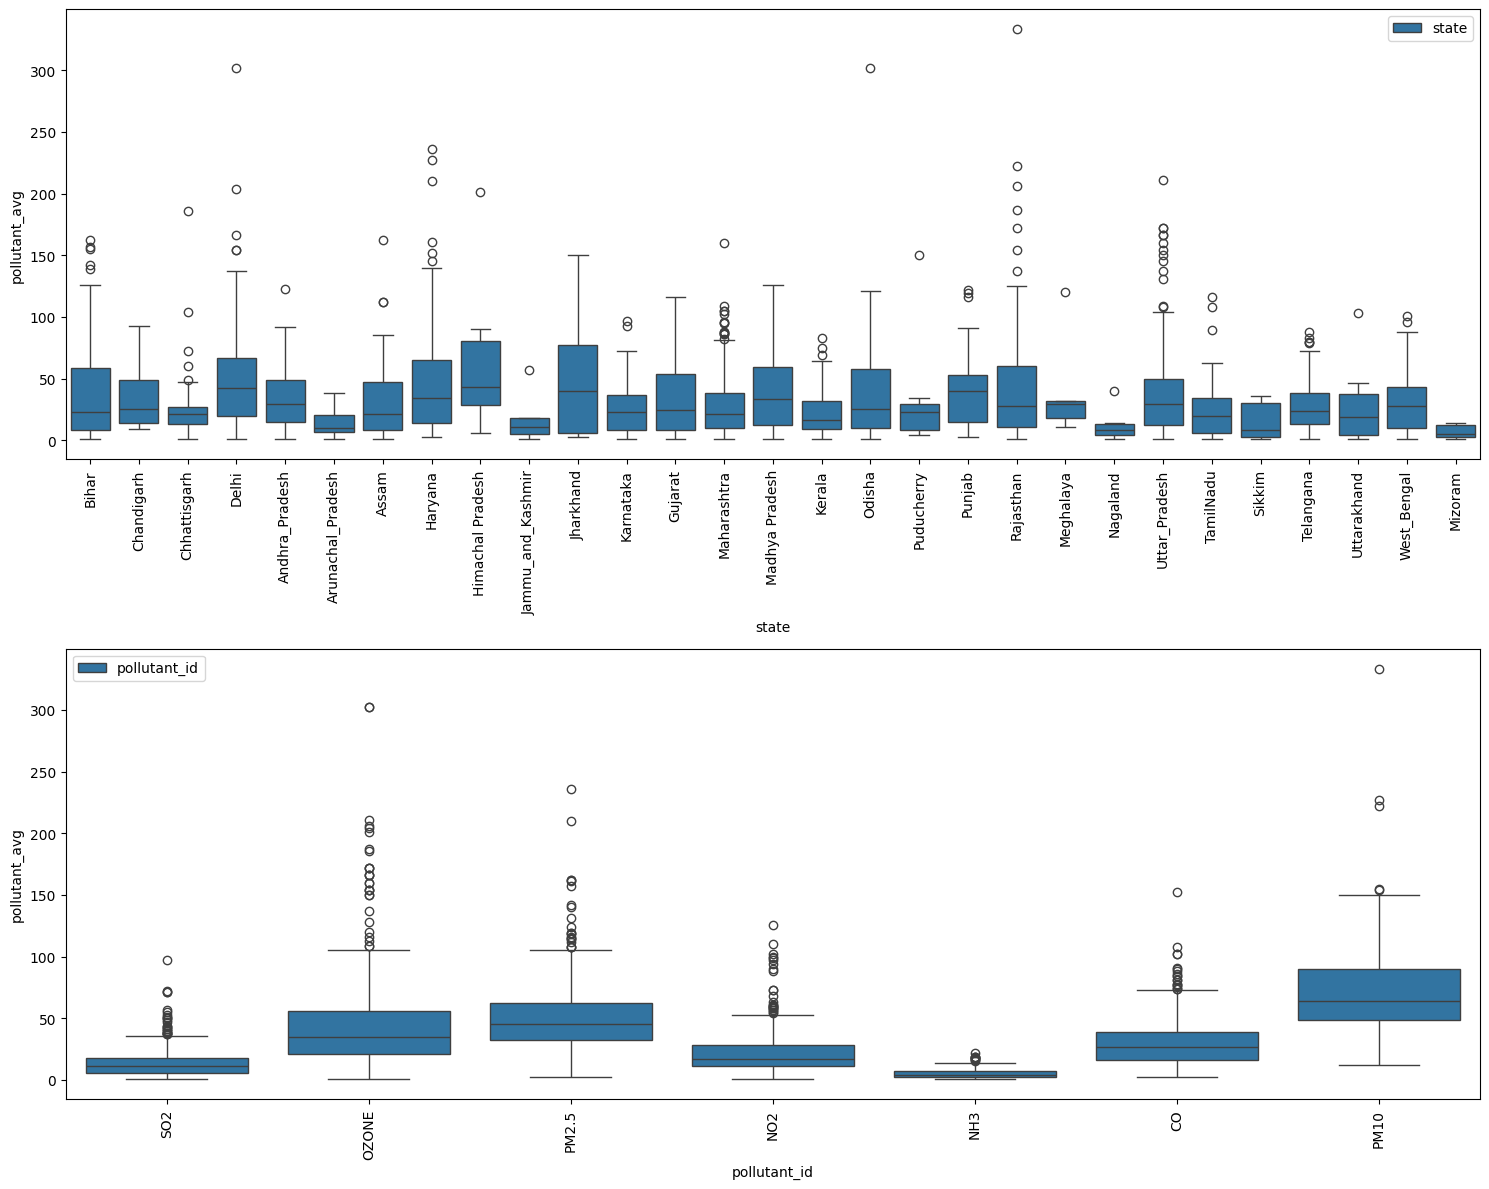

In [15]:
plt.figure(figsize=(15,12))
c=1
for i in cat_data_:
    plt.subplot(2,1,c)
    sns.boxplot(x=data[i],y=data['pollutant_avg'],data=data,label=(i))
    plt.legend()
    plt.xticks(rotation=90)
    c+=1
plt.tight_layout()
plt.show()

# Data Preprocessing(missing values,outliers)

In [16]:
city_unique=data['city'].unique()
state_unique=data['state'].unique()

In [17]:
state_unique

<ArrowStringArray>
[            'Bihar',        'Chandigarh',      'Chhattisgarh',
             'Delhi',    'Andhra_Pradesh', 'Arunachal_Pradesh',
             'Assam',           'Haryana',  'Himachal Pradesh',
 'Jammu_and_Kashmir',         'Jharkhand',         'Karnataka',
           'Gujarat',       'Maharashtra',    'Madhya Pradesh',
            'Kerala',            'Odisha',        'Puducherry',
            'Punjab',         'Rajasthan',         'Meghalaya',
          'Nagaland',     'Uttar_Pradesh',         'TamilNadu',
            'Sikkim',         'Telangana',       'Uttarakhand',
       'West_Bengal',           'Mizoram']
Length: 29, dtype: str

In [18]:
ind_stats=[
  "Andhra Pradesh",
  "Arunachal Pradesh",
  "Assam",
  "Bihar",
  "Chhattisgarh",
  "Goa",
  "Gujarat",
  "Haryana",
  "Himachal Pradesh",
    "Jammu and Kashmir",
  "Jharkhand",
  "Karnataka",
  "Kerala",
  "Madhya Pradesh",
  "Maharashtra",
  "Manipur",
  "Meghalaya",
  "Mizoram",
  "Nagaland",
  "Odisha",
  "Punjab",
  "Rajasthan",
  "Sikkim",
  "Tamil Nadu",
  "Telangana",
  "Tripura",
  "Uttar Pradesh",
  "Uttarakhand",
  "West Bengal"
]

In [19]:
for i in state_unique:
    if i not in ind_stats:
        print(i)

Chandigarh
Delhi
Andhra_Pradesh
Arunachal_Pradesh
Jammu_and_Kashmir
Puducherry
Uttar_Pradesh
TamilNadu
West_Bengal


In [20]:
for i in city_unique:
    if i in ind_stats:
        print(i)
            
        
        

In [21]:
data[data['state']=='Chandigarh'].head(2)

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
14,India,Chandigarh,Chandigarh,"Sector 22, Chandigarh - CPCC",01-06-2026 17:00:00,30.735567,76.775714,PM2.5,2.0,68.0,26.0
15,India,Chandigarh,Chandigarh,"Sector 22, Chandigarh - CPCC",01-06-2026 17:00:00,30.735567,76.775714,PM10,11.0,67.0,37.0


In [22]:
data['pollu']=pd.cut(data['pollutant_avg'],bins=[0,5,10,20,30,40,50,80,120,160,220,np.inf],labels=[1,2,3,4,5,6,7,8,9,10,11])


In [23]:
num_data_=['latitude', 'longitude', 'pollutant_min', 'pollutant_max']
data['state']=data['state'].replace(to_replace="Chandigarh",value='Punjab')

data['state']=data['state'].str.replace("_"," ")

In [24]:
# here i am handle the important feature of categorical by using - chi-square test
from scipy.stats import chi2_contingency
for i  in  cat_data.columns:
    table=pd.crosstab(cat_data[i], data['pollu'])
    _,p_value,_,_=chi2_contingency(table)
    print(f' The colunm is {i},p-value{p_value}')



 The colunm is country,p-value1.0
 The colunm is state,p-value1.1293537041369837e-16
 The colunm is city,p-value2.148397891576235e-06
 The colunm is station,p-value0.7398463378641328
 The colunm is last_update,p-value1.0
 The colunm is pollutant_id,p-value0.0


In [25]:
data['pollu']=data['pollu'].fillna(data['pollu'].mode()[0])

In [26]:
data['pollu'].isnull().sum()

np.int64(0)

In [27]:
y=data['pollu']
x=data.drop('pollu',axis=1)


In [28]:
# Here i drop the garbage cat_col
data=data.drop(['country','last_update','pollu','longitude'],axis=1)
             

# Here we are seprate the test and train data

In [29]:
from sklearn.model_selection import StratifiedShuffleSplit
splits=StratifiedShuffleSplit(n_splits=1,test_size=0.25,random_state=42)
for train,test in splits.split(x,y):
    strat_train=data.loc[train]
    strat_test=data.loc[test]
    train=strat_train.copy()
    test=strat_test.copy()

In [30]:
# Normal approach for handle missing values
# pollu_min=data['pollutant_min'].fillna(data['pollutant_min'].median())
# pollu_max=data['pollutant_max'].fillna(data['pollutant_max'].median())
# pollu_avg=data['pollutant_avg'].fillna(data['pollutant_avg'].median())


In [31]:
#Advanced Approch for handling missing values
pollu_min=train.groupby('state')['pollutant_min'].median()
pollu_max=train.groupby('state')['pollutant_max'].median()
pollu_avg=train.groupby('state')['pollutant_avg'].median()



In [32]:
# Train data missing value
train['pollutant_max']=train['pollutant_max'].fillna(train['state'].map(pollu_max))
train['pollutant_min']=train['pollutant_min'].fillna(train['state'].map(pollu_min))
train['pollutant_avg']=train['pollutant_avg'].fillna(train['state'].map(pollu_avg))
# Test data missing values
test['pollutant_max']=test['pollutant_max'].fillna(test['state'].map(pollu_max))
test['pollutant_min']=test['pollutant_min'].fillna(test['state'].map(pollu_min))
test['pollutant_avg']=test['pollutant_avg'].fillna(test['state'].map(pollu_avg))

In [33]:
train=train.drop(['state','city'],axis=1)
test=test.drop(['state','city'],axis=1)

In [34]:
train_label=train['pollutant_avg']
train=train.drop('pollutant_avg',axis=1)
test_label=test['pollutant_avg']
test=test.drop('pollutant_avg',axis=1)

In [35]:
num_train=train.select_dtypes(include=np.number)
cat_train=train.select_dtypes(exclude=np.number)

In [36]:
# Here we are handling only train data outliers not test data outliers.
for i in num_train:
    q1,q3=np.quantile(train[i],[0.25,0.95])
    iqr=q3-q1
    ul=q3+(1.5*iqr)
    ll=q1-(1.5*iqr)
    ll,ul=np.quantile(train[i],[0.10,0.90])
    train.loc[train[i]>ul,i]=ul
    train.loc[train[i]<ll,i]=ll

In [37]:
# Check the relation between cat-feature  :
# from scipy.stats import chi2_contingency
# for i in cat_train:
#     for j in cat_train:
#         if i!=j:
#             table=pd.crosstab(cat_train[i],cat_train[j])
#             _,p_value,_,_=chi2_contingency(table)

#             if p_value<0.05:
#                 print(f"{i} and {j} have p_value is {p_value}")
                

# Statistics approach

In [38]:
# from statsmodels.formula.api import ols
import statsmodels.stats.api as ssa
import statsmodels.api as sma
ols_model=sma.OLS(train_label,sma.add_constant(num_train)).fit()
ols_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          pollutant_avg   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     3458.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:10:38   Log-Likelihood:                -9700.1
No. Observations:                2471   AIC:                         1.941e+04
Df Residuals:                    2466   BIC:                         1.944e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.5503      4.046     -0.630      0.529     -10.485       5.384
latitude          0.1693      0.049      3.438      0.001       0.073       0.266
longitude         0.0125      0.051      0.247      0.805      -0.087       0.112
pollutant_min     0.7119      0.016     45.492      0.000       0.681       0.743
pollutant_max     0.3270      0.005     61.561      0.000       0.317       0.337
==============================================================================
Omnibus:                     1850.393   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           168606.928
Skew:                           2.827   Prob(JB):                         0.00
Kurtosis:                      43.071   Cond. No.                     1.76e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.76e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [39]:
# Linerity approach
sma.stats.linear_rainbow(ols_model)

(np.float64(1.8309807892371968), np.float64(2.9674592662742743e-26))

In [40]:
num_data=data.select_dtypes(include=np.number)

In [41]:
correlation=data[num_data.columns].corr()
print(correlation)

               latitude  longitude  pollutant_min  pollutant_max  \
latitude       1.000000   0.093594       0.105213       0.173225   
longitude      0.093594   1.000000      -0.011498      -0.027415   
pollutant_min  0.105213  -0.011498       1.000000       0.561396   
pollutant_max  0.173225  -0.027415       0.561396       1.000000   
pollutant_avg  0.184279  -0.018656       0.774609       0.840773   

               pollutant_avg  
latitude            0.184279  
longitude          -0.018656  
pollutant_min       0.774609  
pollutant_max       0.840773  
pollutant_avg       1.000000  


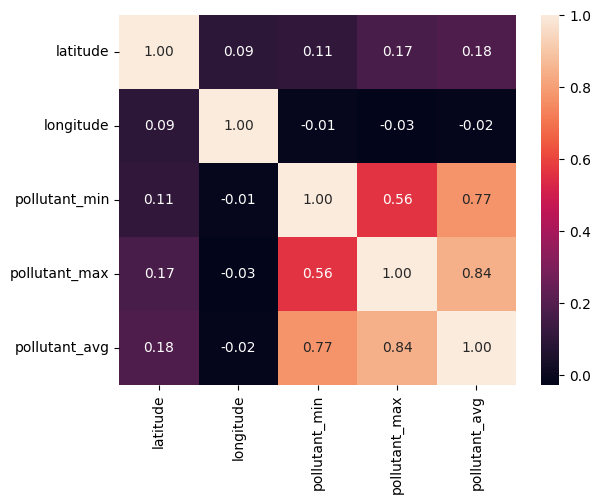

In [42]:
# multicolenearity approach

sns.heatmap(correlation,annot=True,fmt='.2f')
plt.show()

In [43]:
correlation1=num_data.corr()['pollutant_avg'].sort_values()
print(correlation1)

longitude       -0.018656
latitude         0.184279
pollutant_min    0.774609
pollutant_max    0.840773
pollutant_avg    1.000000
Name: pollutant_avg, dtype: float64


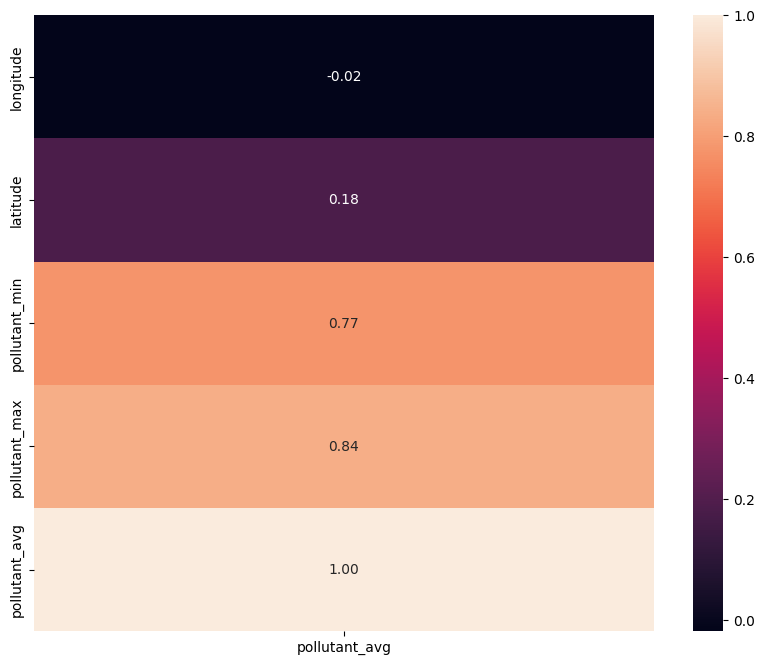

In [44]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation1.to_frame(),annot=True,fmt='.2f')
plt.show()

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_list=[]
for i in range(num_train.shape[1]):
    vif_list.append(variance_inflation_factor(num_train.values,i))
vif=pd.DataFrame({'features':num_train.columns,'values':vif_list})
vif.sort_values(ascending=False,by='values')

,features,values
0,latitude,21.934895
1,longitude,21.336288
2,pollutant_min,2.991443
3,pollutant_max,2.921392


In [46]:
# Autocorrelation
from statsmodels.stats.stattools import durbin_watson
durbin_watson(ols_model.resid)

np.float64(2.042761508751421)

In [47]:
# Hetrosacdacity
ssa.het_breuschpagan(ols_model.resid,sma.add_constant(ols_model.model.exog))

(np.float64(525.280785471039),
 np.float64(2.278970271549025e-112),
 np.float64(166.43491097007694),
 np.float64(2.7789920911611433e-126))

In [48]:
from sklearn.ensemble import RandomForestRegressor
rs=RandomForestRegressor()

In [49]:
from mlxtend.feature_selection import SequentialFeatureSelector as sfa
selection=sfa(estimator=rs,k_features='best',forward=True,scoring='neg_mean_squared_error')
selection=selection.fit(sma.add_constant(num_train),train_label)
print(selection.k_feature_names_)

('latitude', 'longitude', 'pollutant_min', 'pollutant_max')


In [50]:
from sklearn.feature_selection import RFE
selection=RFE(estimator=rs,n_features_to_select=4)
selection=selection.fit(sma.add_constant(num_train),train_label)
pd.Series(selection.ranking_,index=sma.add_constant(num_train).columns)

const            2
latitude         1
longitude        1
pollutant_min    1
pollutant_max    1
dtype: int64

In [51]:
from scipy.stats import tukey_hsd
result=tukey_hsd(*[num_train[col].dropna() for col in num_train.columns])
print(result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -55.358     0.000   -57.585   -53.131
 (0 - 2)      3.883     0.000     1.656     6.110
 (0 - 3)    -31.757     0.000   -33.984   -29.530
 (1 - 0)     55.358     0.000    53.131    57.585
 (1 - 2)     59.241     0.000    57.014    61.469
 (1 - 3)     23.601     0.000    21.374    25.828
 (2 - 0)     -3.883     0.000    -6.110    -1.656
 (2 - 1)    -59.241     0.000   -61.469   -57.014
 (2 - 3)    -35.641     0.000   -37.868   -33.414
 (3 - 0)     31.757     0.000    29.530    33.984
 (3 - 1)    -23.601     0.000   -25.828   -21.374
 (3 - 2)     35.641     0.000    33.414    37.868



# Machine Pipeline approach :

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler , TargetEncoder



In [53]:
num_pipeline=Pipeline([('imput',SimpleImputer(strategy='median')),('scaler',RobustScaler())])
cat_pipeline=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('scaler',TargetEncoder())])
merge_pipeline=ColumnTransformer([('num_data',num_pipeline,num_train.columns),('cat_data',cat_pipeline,cat_train.columns)])

In [54]:
prepared=merge_pipeline.fit_transform(train,train_label)
prepared_test=merge_pipeline.transform(test)

In [55]:
random=RandomForestRegressor(max_depth=10,n_estimators=100,min_samples_leaf=5,max_leaf_nodes=120,random_state=42,n_jobs=-1)

In [56]:
from sklearn.model_selection import GridSearchCV
# parameters={
#     'max_depth':[1,3,5,7,10,15],
#     'n_estimators':[50,70,100,130,150,200],
#     'min_samples_leaf':[1,2,5,10,20],
#     'max_leaf_nodes':[10,20,30,50,100,120]}
# searching=GridSearchCV(random,param_grid=parameters,cv=3,scoring='neg_mean_squared_error')
# all_search =searching.fit(prepared,train_label)
# print(all_search.best_params_)


In [57]:
random_prepared=random.fit(prepared,train_label)
prediction=random_prepared.predict(prepared_test)

In [58]:
from sklearn.metrics import classification_report,root_mean_squared_error,confusion_matrix,accuracy_score,r2_score

In [59]:
importance=random_prepared.feature_importances_
feature=merge_pipeline.get_feature_names_out()
imp_feature=pd.DataFrame({
    'Feature':feature,'Importance':importance}).sort_values(ascending=True,by='Importance')
print(imp_feature)

                   Feature  Importance
4        cat_data__station    0.013643
0       num_data__latitude    0.019320
1      num_data__longitude    0.021271
5   cat_data__pollutant_id    0.035103
2  num_data__pollutant_min    0.091306
3  num_data__pollutant_max    0.819358


In [60]:
from sklearn.model_selection import cross_val_score
scoring=cross_val_score(random,prepared,train_label,cv=10,scoring='neg_root_mean_squared_error',n_jobs=-1)
print(scoring)

[-12.89402582 -14.73947957  -8.38929025 -10.458973   -13.75831685
 -10.71610691 -10.5649394  -18.06624163 -17.05495766 -11.36842497]


In [61]:
rmse=root_mean_squared_error(test_label,prediction)
print(rmse)

11.447003033365176


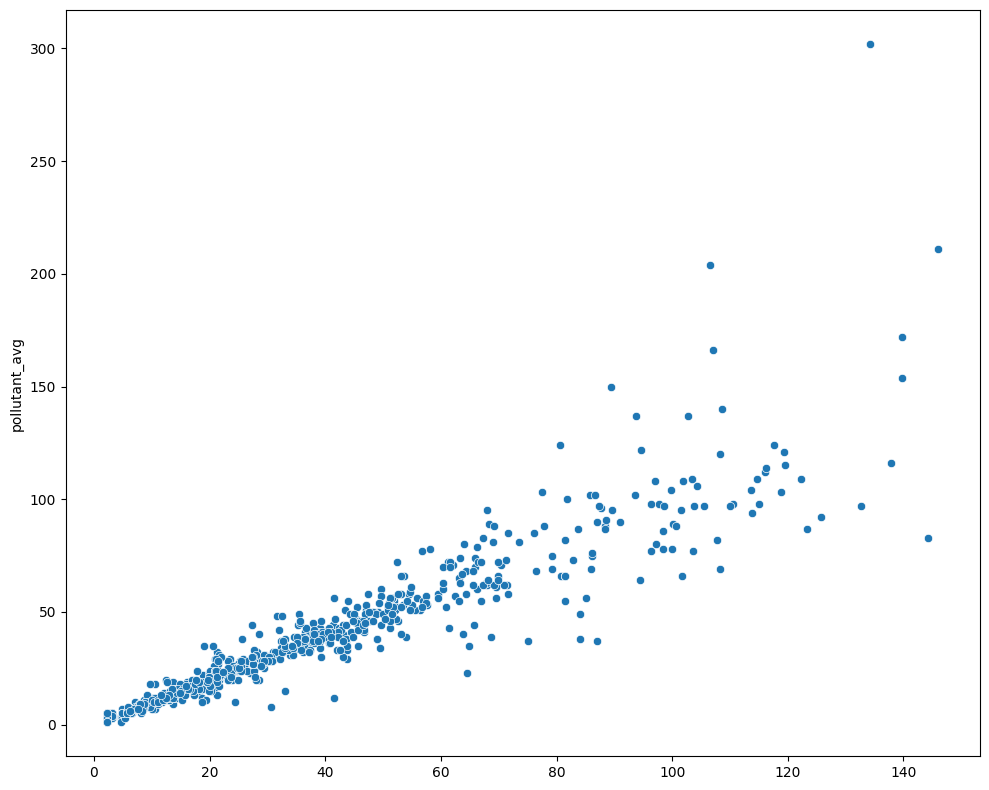

In [62]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=prediction,y=test_label)
plt.tight_layout()
plt.show()

In [63]:
r2=r2_score(test_label,prediction)
print(r2)

0.8657573256973795


In [64]:
from xgboost import XGBRegressor


In [65]:
boost=XGBRegressor(max_depth=5,learning_rate=0.03,n_estimators=500,min_child_weight= 10 , random_state=42,n_jobs=-1)

In [66]:
boost_prepared=boost.fit(prepared,train_label)
predictions=boost_prepared.predict(prepared_test)

In [67]:
r2=r2_score(test_label,predictions)
print(r2)

0.8561355707902859


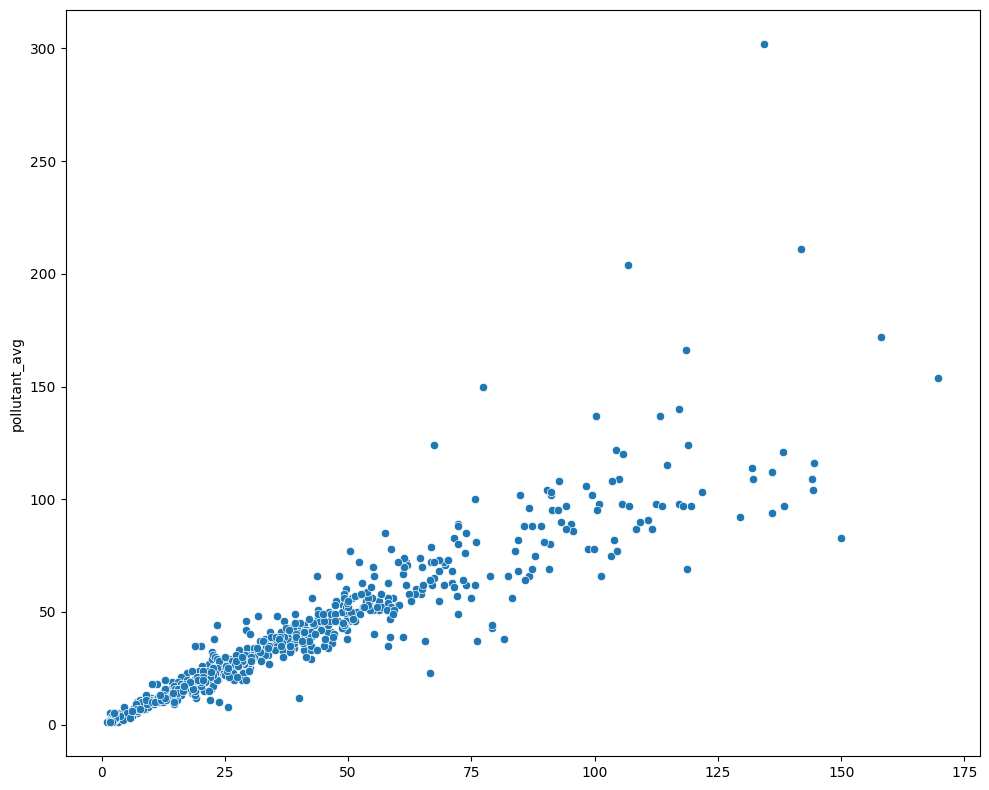

In [68]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=predictions,y=test_label)
plt.tight_layout()
plt.show()

In [69]:
# from sklearn.model_selection import GridSearchCV
# parameteres={
#     'max_depth':[1,3,5,7,10,15],
#     'n_estimators':[50,70,100,130,150,200],
#     'min_child_weight':[1,2,5,10,20],
#     'learning_rate':[0.001,0.01,0.002,0.02,0.03,0.04]}
# searchings=GridSearchCV(boost,param_grid=parameteres,cv=3,scoring='neg_mean_squared_error',n_jobs=-1)
# all_searchs =searchings.fit(prepared,train_label)
# print(all_searchs.best_params_)
